In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Încărcarea seturilor de date din folderul data/
# Folosim "../data/" deoarece notebook-ul se află în folderul notebooks, deci urcăm un nivel în sus
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

# 2. Adăugarea etichetelor (0 pentru Fake, 1 pentru True)
fake["label"] = 0
true["label"] = 1

# 3. Combinarea celor două seturi de date într-un singur Dataframe
df = pd.concat([fake, true], ignore_index=True)

# 4. Afișarea primelor 5 rânduri ca să verificăm că totul e în regulă
print("Datele au fost încărcate cu succes!")
df.head()

Datele au fost încărcate cu succes!


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Număr total de articole: 44898

Distribuția claselor (Fake vs Real):
label
0    23481
1    21417
Name: count, dtype: int64

Valori lipsă pe fiecare coloană:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


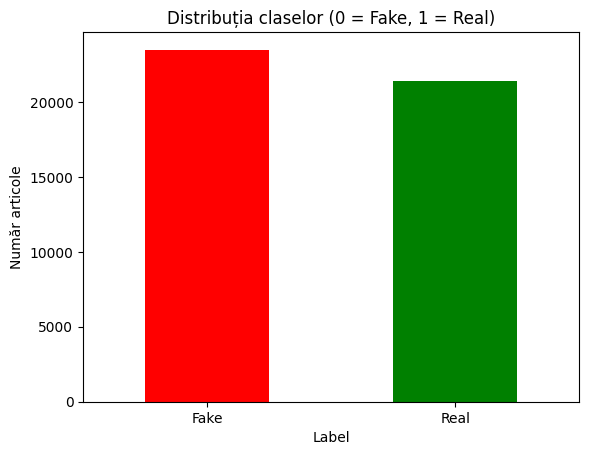

In [2]:
# Verificăm dimensiunea totală și distribuția claselor
print(f"Număr total de articole: {df.shape[0]}")
print("\nDistribuția claselor (Fake vs Real):")
print(df["label"].value_counts())

# Verificăm dacă există valori lipsă (NaN)
print("\nValori lipsă pe fiecare coloană:")
print(df.isnull().sum())

# Generarea graficului solicitat
df["label"].value_counts().plot(kind="bar", color=['red', 'green'])
plt.title("Distribuția claselor (0 = Fake, 1 = Real)")
plt.xlabel("Label")
plt.ylabel("Număr articole")
plt.xticks(ticks=[0, 1], labels=['Fake', 'Real'], rotation=0)
plt.show()

Datasetul conține articole reale și articole false. Fiecare articol are un titlu, un text, o categorie și o dată. Pentru proiect folosim textul și titlul articolului, iar labelul indică dacă articolul este fake sau real.

Acum creem coloana CONTENT care are si textul si titlul in aceeasi coloana.

In [4]:
# Înlocuim eventualele valori lipsă cu text gol ca să nu primim erori la concatenare
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

# Combinăm titlul și textul într-o singură coloană numită 'content'
df["content"] = df["title"] + " " + df["text"]

# Verificăm rezultatul pe primul articol (afișăm doar primele 300 de caractere)
print("Coloana 'content' a fost creată cu succes!")
print(df["content"].iloc[0][:300])

Coloana 'content' a fost creată cu succes!
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had j


In [5]:
# Luăm un eșantion aleatoriu de 3000 de articole fake și 3000 reale
fake_sample = df[df["label"] == 0].sample(3000, random_state=42)
true_sample = df[df["label"] == 1].sample(3000, random_state=42)

# Le unim din nou și le amestecăm bine (shuffle)
df_subset = pd.concat([fake_sample, true_sample], ignore_index=True)
df_subset = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dimensiunea datasetului redus: {df_subset.shape}")
print(df_subset["label"].value_counts())

Dimensiunea datasetului redus: (6000, 6)
label
0    3000
1    3000
Name: count, dtype: int64


In [6]:
import sys
# Ne asigurăm că Python știe să caute module în folderul 'src' (urcăm un nivel în sus)
sys.path.append("../")

from src.preprocessing import clean_text

# Aplicăm funcția de curățare pe subsetul nostru de date
print("Agentul 1 curăță textul... (poate dura câteva secunde)")
df_subset["clean_content"] = df_subset["content"].apply(clean_text)

# Eliminăm eventualele articole care au rămas goale după curățare
df_subset = df_subset[df_subset["clean_content"].str.len() > 0]

print(f"Curățare finalizată! Dimensiune dataset: {df_subset.shape}")
# Afișăm o comparație între textul brut și textul curățat
df_subset[["content", "clean_content", "label"]].head()

Agentul 1 curăță textul... (poate dura câteva secunde)
Curățare finalizată! Dimensiune dataset: (5999, 7)


,content,clean_content,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,watch trump just told all the anti gay bigots ...,0
1,"China backs U.N. call for justice in Yemen, U....",china backs u n call for justice in yemen u s ...,1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,the people s president trump meets with coal w...,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,wsj reporter rips into dem candidates for thei...,0
4,Lawmakers aim to delay U.S. ceding control of ...,lawmakers aim to delay u s ceding control of i...,1


In [7]:
# Selectăm doar coloanele importante cerute în proiect
df_final = df_subset[["content", "clean_content", "label"]]

# Salvăm datele în fișierul processed_news.csv din folderul data
# Folosim ../ deoarece suntem în folderul notebooks
df_final.to_csv("../data/processed_news.csv", index=False)

print("Succes! Datele au fost salvate în data/processed_news.csv")

Succes! Datele au fost salvate în data/processed_news.csv
